# Projet end-to-end de ML pour la detection des fraudes à l'assurance automobile

Le dataset contient des informations sur les véhicules ainsi que les données liées aux contrats d'assurance (type de police, durée..)

L'objectif est de determiner si une demande d'indemnisation est frauduleuse ou non.

## Import des librairies

In [28]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import  LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score

from sklearn.metrics import roc_curve, auc, RocCurveDisplay

## Chargement du dataset



In [4]:
path = "input/fraud_oracle.csv"
df = pd.read_csv(path)



In [5]:
# Affichage des premières lignes
print(f" Shape : {df.shape}")
print("--------------")
print(df.head())
print("--------------")
print(df.info())
print("--------------")
print(df.describe())
print("--------------")

print(df.isna().sum())
print(df.corr(numeric_only=True))

# Pas de columns avec des valeurs vides


 Shape : (15420, 33)
--------------
  Month  WeekOfMonth  DayOfWeek    Make AccidentArea DayOfWeekClaimed  \
0   Dec            5  Wednesday   Honda        Urban          Tuesday   
1   Jan            3  Wednesday   Honda        Urban           Monday   
2   Oct            5     Friday   Honda        Urban         Thursday   
3   Jun            2   Saturday  Toyota        Rural           Friday   
4   Jan            5     Monday   Honda        Urban          Tuesday   

  MonthClaimed  WeekOfMonthClaimed     Sex MaritalStatus  ...  AgeOfVehicle  \
0          Jan                   1  Female        Single  ...       3 years   
1          Jan                   4    Male        Single  ...       6 years   
2          Nov                   2    Male       Married  ...       7 years   
3          Jul                   1    Male       Married  ...   more than 7   
4          Feb                   2  Female        Single  ...       5 years   

  AgeOfPolicyHolder PoliceReportFiled WitnessPrese

In [6]:
# EXPLORATION RAPIDE DES DONNEES
# Afficher la forme du dataset et les colonnes
print("\n")
print(f"Forme du dataset: {df.shape}")
print("\n")
print(f"Colonnes: {list(df.columns)}")

num_colums = df.select_dtypes(include=np.number).columns.drop("FraudFound_P")
category_columns = df.select_dtypes(include=str).columns
print(f"Colonnes numériques: {list(num_colums)}")
print(f"Colonnes catégorielles: {list(category_columns)}")

# Explorer les types de données et les valeurs manquantes
print("\n")
print("\nTypes de données et valeurs manquantes:")
print(df.info())

print("\n")
print("Valeurs manquantes:")
print(df.isnull().sum())



Forme du dataset: (15420, 33)


Colonnes: ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']
Colonnes numériques: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']
Colonnes catégorielles: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'Polic

In [7]:
# 2.1 EDA - ANALYSE EXPLORATOIRE DÉTAILLÉE
print("\n=== ANALYSE EXPLORATOIRE (EDA) ===")

# Statistiques descriptives
print("Statistiques descriptives:")
#print(df.describe())

#print(df.head())

print(df[category_columns].head(10))





=== ANALYSE EXPLORATOIRE (EDA) ===
Statistiques descriptives:
  Month  DayOfWeek    Make AccidentArea DayOfWeekClaimed MonthClaimed     Sex  \
0   Dec  Wednesday   Honda        Urban          Tuesday          Jan  Female   
1   Jan  Wednesday   Honda        Urban           Monday          Jan    Male   
2   Oct     Friday   Honda        Urban         Thursday          Nov    Male   
3   Jun   Saturday  Toyota        Rural           Friday          Jul    Male   
4   Jan     Monday   Honda        Urban          Tuesday          Feb  Female   
5   Oct     Friday   Honda        Urban        Wednesday          Nov    Male   
6   Feb   Saturday   Honda        Urban           Monday          Feb    Male   
7   Nov     Friday   Honda        Urban          Tuesday          Mar    Male   
8   Dec   Saturday   Honda        Urban        Wednesday          Dec    Male   
9   Apr    Tuesday    Ford        Urban        Wednesday          Apr    Male   

  MaritalStatus          Fault            Pol

Text(0.5, 1.0, 'Matrice de Corrélation')

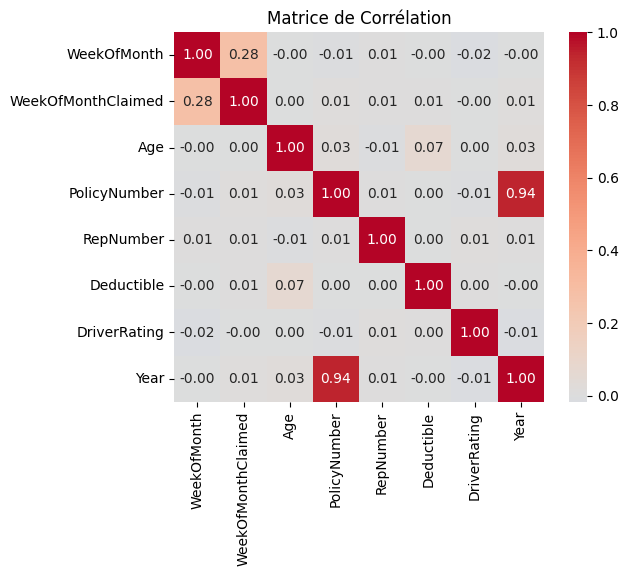

In [8]:
# Matrice de correlation
corr_matrix = df[num_colums].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Matrice de Corrélation')

Text(0, 0.5, 'Âge')

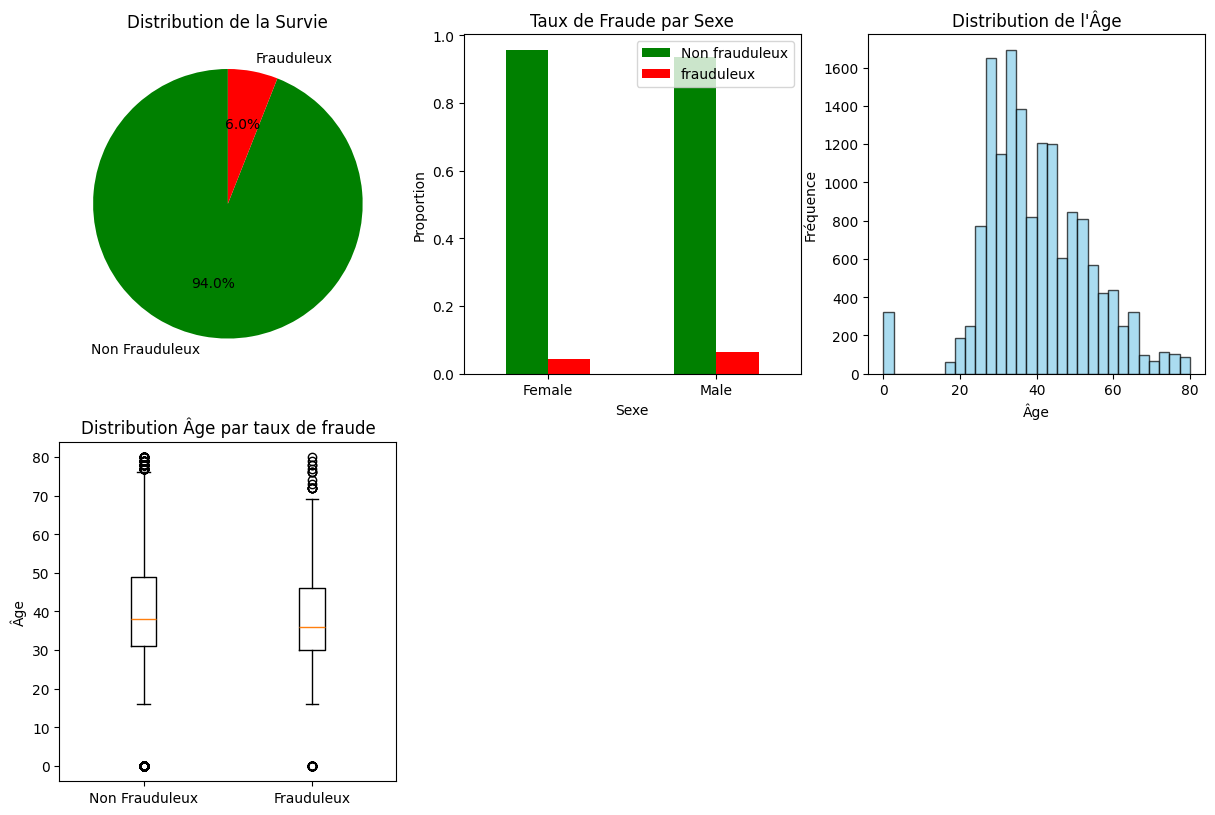

In [9]:
# EDA Visualisations
plt.figure(figsize=(20, 15))

# 1. Distribution de la variable cible
plt.subplot(3, 4, 1)
survival_counts = df['FraudFound_P'].value_counts()
plt.pie(survival_counts.values, labels=['Non Frauduleux', 'Frauduleux'], autopct='%1.1f%%', 
        colors=['green', 'red'], startangle=90)
plt.title('Distribution de la Survie')

# 2. Taux de fraude par sexe
plt.subplot(3, 4, 2)
survival_by_sex = pd.crosstab(df['Sex'], df['FraudFound_P'], normalize='index')
survival_by_sex.plot(kind='bar', color=['green', 'red'], ax=plt.gca())
plt.title('Taux de Fraude par Sexe')
plt.xlabel('Sexe')
plt.ylabel('Proportion')
plt.legend(['Non frauduleux', 'frauduleux'])
plt.xticks(rotation=0)


# 3. Distribution de l'âge
plt.subplot(3, 4, 3)
plt.hist(df['Age'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution de l\'Âge')
plt.xlabel('Âge')
plt.ylabel('Fréquence')

# 4. Taux de fraude par âge (boxplot)
plt.subplot(3, 4, 5)
frauduleux_ages = df[df['FraudFound_P'] == 1]['Age'].dropna()
non_frauduleux_ages = df[df['FraudFound_P'] == 0]['Age'].dropna()
plt.boxplot([non_frauduleux_ages, frauduleux_ages], tick_labels=['Non Frauduleux', 'Frauduleux'])
plt.title('Distribution Âge par taux de fraude')
plt.ylabel('Âge')





## Liste des colonnes à supprimer
- PolicyNumber, RepNumber : qui sont des identifiants et donc n'apportent pas valeur pour l'entrainement
- PoliceReportFiled: rapport de police déposé (potentiellement déposé après l'accident)
- WitnessPresent: Présence de témoin
- NumberOfSuppliments: nombre de justificatifs supplémentaires
- Make: Marque des voitures- nombre de catégories très élevées (19) - on conserve la type de véhicule

In [10]:
# verifier les features catégorielles
print(df[category_columns].nunique().sort_values(ascending=False))

for column in category_columns:
    print(f" {column} : {df[column].unique()}")
    print(f"________________________________")



Make                    19
MonthClaimed            13
Month                   12
PolicyType               9
AgeOfPolicyHolder        9
AgeOfVehicle             8
DayOfWeekClaimed         8
DayOfWeek                7
VehiclePrice             6
AddressChange_Claim      5
Days_Policy_Accident     5
NumberOfCars             5
PastNumberOfClaims       4
NumberOfSuppliments      4
MaritalStatus            4
Days_Policy_Claim        4
BasePolicy               3
VehicleCategory          3
Sex                      2
AccidentArea             2
Fault                    2
AgentType                2
PoliceReportFiled        2
WitnessPresent           2
dtype: int64
 Month : <StringArray>
['Dec', 'Jan', 'Oct', 'Jun', 'Feb', 'Nov', 'Apr', 'Mar', 'Aug', 'Jul', 'May',
 'Sep']
Length: 12, dtype: str
________________________________
 DayOfWeek : <StringArray>
['Wednesday', 'Friday', 'Saturday', 'Monday', 'Tuesday', 'Sunday', 'Thursday']
Length: 7, dtype: str
________________________________
 Make : <Stri

Étape 2 — Explorer les variables catégorielles
→ countplot par rapport à la target
→ corrélation avec Chi-2 / Cramér's V
→ décision : garder ou supprimer

Étape 3 — Explorer les variables continues
→ describe() → métriques
→ boxplot → outliers
→ décision : normaliser, discrétiser
              ou garder tel quel

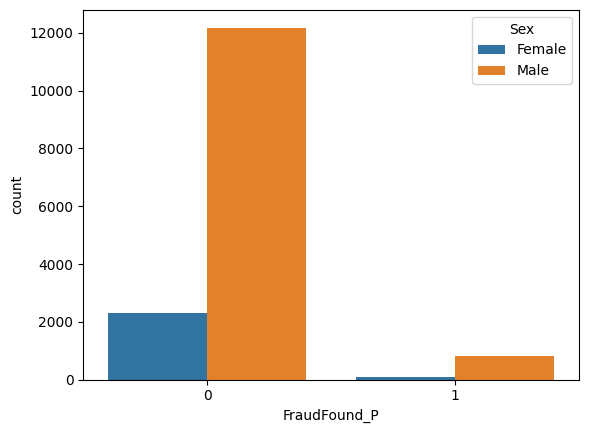

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# read a tips.csv file from seaborn library


# count plot on single categorical variable
sns.countplot(x ='FraudFound_P',hue="Sex", data = df)

plt.show()

## Split donnés entrainement et données de test

In [12]:
X = df.drop(columns=["PolicyNumber", "PoliceReportFiled", "WitnessPresent", "NumberOfSuppliments", "Make", "FraudFound_P", "RepNumber"])
y = df["FraudFound_P"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_colums = X_train.select_dtypes(include=np.number).columns
cat_colums = X_train.select_dtypes(include=np.object_).columns

print(f"num_colums {len(num_colums)}")
print(f"cat_colums {len(cat_colums)}")
print(y_test.shape)
print(y_train.shape)


num_colums 6
cat_colums 20
(3084,)
(12336,)


/tmp/ipykernel_12711/1372413494.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_colums = X_train.select_dtypes(include=np.object_).columns


## Encodage des variables catégorielles

In [13]:
# NumberOfCars
"""col = "NumberOfCars"
col_enc = "NumberOfCars_enc"
cat_column = ['1 vehicle', '2 vehicles', '3 to 4', '5 to 8', 'more than 8']
ord_enc = OrdinalEncoder(categories=[cat_column])

X_train[col_enc] = ord_enc.fit_transform(X_train[[col]])
X_test[col_enc] = ord_enc.transform(X_test[[col]])
print(X_train[[col_enc, col]] )

# VehiclePrice
col = "VehiclePrice"
col_enc = "VehiclePrice_enc"
cat_column = ['less than 20000','20000 to 29000', '30000 to 39000', '40000 to 59000', '60000 to 69000','more than 69000']
ord_enc = OrdinalEncoder(categories=[cat_column])

X_train[col_enc] = ord_enc.fit_transform(X_train[[col]])
X_test[col_enc] = ord_enc.transform(X_test[[col]])
print(X_train[[col_enc, col]] )


# Days_Policy_Claim
col = "Days_Policy_Claim"
col_enc = "Days_Policy_Claim_enc"
cat_column= ['none', '8 to 15', '15 to 30','more than 30' ]
ord_enc = OrdinalEncoder(categories=[cat_column])

X_train[col_enc] = ord_enc.fit_transform(X_train[[col]])
X_test[col_enc] = ord_enc.transform(X_test[[col]])
print(X_train[[col_enc, col]] )

# Days_Policy_Accident
col = "Days_Policy_Accident"
col_enc = "Days_Policy_Accident_enc"
cat_column= ['none', '1 to 7','8 to 15', '15 to 30','more than 30' ]
ord_enc = OrdinalEncoder(categories=[cat_column])

X_train[col_enc] = ord_enc.fit_transform(X_train[[col]])
X_test[col_enc] = ord_enc.transform(X_test[[col]])
print(X_train[[col_enc, col]] )

# PastNumberOfClaims
col = "PastNumberOfClaims"
col_enc = "PastNumberOfClaims_enc"
cat_column= ['none', '1', '2 to 4', 'more than 4']
ord_enc = OrdinalEncoder(categories=[cat_column])

X_train[col_enc] = ord_enc.fit_transform(X_train[[col]])
X_test[col_enc] = ord_enc.transform(X_test[[col]])
print(X_train[[col_enc, col]] )

# AgeOfVehicle
col = "AgeOfVehicle"
col_enc = "AgeOfVehicle_enc"
cat_column= [ 'new',   '2 years', '3 years', '4 years',  '5 years',  '6 years',     '7 years', 'more than 7'  ]
ord_enc = OrdinalEncoder(categories=[cat_column])

X_train[col_enc] = ord_enc.fit_transform(X_train[[col]])
X_test[col_enc] = ord_enc.transform(X_test[[col]])
print(X_train[[col_enc, col]] )

# AgeOfPolicyHolder
col = "AgeOfPolicyHolder"
col_enc = "AgeOfPolicyHolder_enc"
cat_column= ['16 to 17','18 to 20', '21 to 25','26 to 30', '31 to 35','36 to 40', '41 to 50', '51 to 65','over 65']
ord_enc = OrdinalEncoder(categories=[cat_column])

X_train[col_enc] = ord_enc.fit_transform(X_train[[col]])
X_test[col_enc] = ord_enc.transform(X_test[[col]])
print(X_train[[col_enc, col]] )

# AddressChange_Claim
col = "AddressChange_Claim"
col_enc = "AddressChange_Claim_enc"
cat_column= ['no change', 'under 6 months', '1 year', '2 to 3 years', '4 to 8 years']
ord_enc = OrdinalEncoder(categories=[cat_column])

X_train[col_enc] = ord_enc.fit_transform(X_train[[col]])
X_test[col_enc] = ord_enc.transform(X_test[[col]])
print(X_train[[col_enc, col]] )

# Month
col = "Month"
col_enc = "Month_enc"
cat_column= ['Jan', 'Feb', 'Mar','Apr', 'May','Jun','Jul', 'Aug','Sep','Oct', 'Nov','Dec' ]
ord_enc = OrdinalEncoder(categories=[cat_column])

X_train[col_enc] = ord_enc.fit_transform(X_train[[col]])
X_test[col_enc] = ord_enc.transform(X_test[[col]])
print(X_train[[col_enc, col]] )

# DayOfWeek
col = "DayOfWeek"
col_enc = "DayOfWeek_enc"
cat_column= ['Sunday','Monday','Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday' ]
ord_enc = OrdinalEncoder(categories=[cat_column])

X_train[col_enc] = ord_enc.fit_transform(X_train[[col]])
X_test[col_enc] = ord_enc.transform(X_test[[col]])
print(X_train[[col_enc, col]] )

# DayOfWeekClaimed
col = "DayOfWeekClaimed"
col_enc = "DayOfWeekClaimed_enc"
cat_column= ['0', 'Sunday','Monday','Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday' ]
ord_enc = OrdinalEncoder(categories=[cat_column])

X_train[col_enc] = ord_enc.fit_transform(X_train[[col]])
X_test[col_enc] = ord_enc.transform(X_test[[col]])
print(X_train[[col_enc, col]] )

# MonthClaimed
col = "MonthClaimed"
col_enc = "MonthClaimed_enc"
cat_column= ['0', 'Jan', 'Feb', 'Mar','Apr', 'May','Jun','Jul', 'Aug','Sep','Oct', 'Nov','Dec' ]
ord_enc = OrdinalEncoder(categories=[cat_column])

X_train[col_enc] = ord_enc.fit_transform(X_train[[col]])
X_test[col_enc] = ord_enc.transform(X_test[[col]])
print(X_train[[col_enc, col]] )"""

'col = "NumberOfCars"\ncol_enc = "NumberOfCars_enc"\ncat_column = [\'1 vehicle\', \'2 vehicles\', \'3 to 4\', \'5 to 8\', \'more than 8\']\nord_enc = OrdinalEncoder(categories=[cat_column])\n\nX_train[col_enc] = ord_enc.fit_transform(X_train[[col]])\nX_test[col_enc] = ord_enc.transform(X_test[[col]])\nprint(X_train[[col_enc, col]] )\n\n# VehiclePrice\ncol = "VehiclePrice"\ncol_enc = "VehiclePrice_enc"\ncat_column = [\'less than 20000\',\'20000 to 29000\', \'30000 to 39000\', \'40000 to 59000\', \'60000 to 69000\',\'more than 69000\']\nord_enc = OrdinalEncoder(categories=[cat_column])\n\nX_train[col_enc] = ord_enc.fit_transform(X_train[[col]])\nX_test[col_enc] = ord_enc.transform(X_test[[col]])\nprint(X_train[[col_enc, col]] )\n\n\n# Days_Policy_Claim\ncol = "Days_Policy_Claim"\ncol_enc = "Days_Policy_Claim_enc"\ncat_column= [\'none\', \'8 to 15\', \'15 to 30\',\'more than 30\' ]\nord_enc = OrdinalEncoder(categories=[cat_column])\n\nX_train[col_enc] = ord_enc.fit_transform(X_train[[col]

### OnHotEncoder

In [14]:
# AccidentArea, Sex, MaritalStatus, Fault, PolicyType, VehicleCategory, AgentType, BasePolicy
"""cat_cols = ["AccidentArea", "Sex", "MaritalStatus", "Fault", "PolicyType", "VehicleCategory", "AgentType", "BasePolicy"]
oneHot = OneHotEncoder(handle_unknown='ignore')
X_train_cat = oneHot.fit_transform(X_train[cat_cols])
X_test_cat  = oneHot.transform(X_test[cat_cols])

# Concat
#X_train_prepared = hstack([X_train_num, X_train_cat])"""



'cat_cols = ["AccidentArea", "Sex", "MaritalStatus", "Fault", "PolicyType", "VehicleCategory", "AgentType", "BasePolicy"]\noneHot = OneHotEncoder(handle_unknown=\'ignore\')\nX_train_cat = oneHot.fit_transform(X_train[cat_cols])\nX_test_cat  = oneHot.transform(X_test[cat_cols])\n\n# Concat\n#X_train_prepared = hstack([X_train_num, X_train_cat])'

## Scaling des variables numériques

In [15]:

#print(num_colums)

"""scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[num_colums])
X_test_num_scaled = scaler.transform(X_test[num_colums])
print("Train:", X_train_num_scaled.shape, "Test:", X_test_num_scaled.shape)"""


'scaler = StandardScaler()\nX_train_num_scaled = scaler.fit_transform(X_train[num_colums])\nX_test_num_scaled = scaler.transform(X_test[num_colums])\nprint("Train:", X_train_num_scaled.shape, "Test:", X_test_num_scaled.shape)'

In [16]:
# Concatenation des colonnes X_train_num_scaled, X_train_cat et colonnes avec ordinalEncoder
"""ordinal_enc_cols = ["NumberOfCars_enc", "VehiclePrice_enc", "Days_Policy_Claim_enc", 
                    "Days_Policy_Accident_enc", "PastNumberOfClaims_enc", "AgeOfVehicle_enc", 
                    "AgeOfPolicyHolder_enc", "AddressChange_Claim_enc", "Month", "DayOfWeek_enc", "DayOfWeekClaimed_enc", "MonthClaimed_enc"]


print(f" X_train_num_scaled {X_train_num_scaled.shape}")
print(f" X_train_cat {X_train_cat.shape}")
print(f" ordinal_enc_cols {X_train[ordinal_enc_cols].shape}")
#X_train_prepared = hstack([X_train_num_scaled, X_train_cat])
#X_train_prepared = hstack([X_test_num_scaled, X_test_cat, X_test[ordinal_enc_cols]])"""

'ordinal_enc_cols = ["NumberOfCars_enc", "VehiclePrice_enc", "Days_Policy_Claim_enc", \n                    "Days_Policy_Accident_enc", "PastNumberOfClaims_enc", "AgeOfVehicle_enc", \n                    "AgeOfPolicyHolder_enc", "AddressChange_Claim_enc", "Month", "DayOfWeek_enc", "DayOfWeekClaimed_enc", "MonthClaimed_enc"]\n\n\nprint(f" X_train_num_scaled {X_train_num_scaled.shape}")\nprint(f" X_train_cat {X_train_cat.shape}")\nprint(f" ordinal_enc_cols {X_train[ordinal_enc_cols].shape}")\n#X_train_prepared = hstack([X_train_num_scaled, X_train_cat])\n#X_train_prepared = hstack([X_test_num_scaled, X_test_cat, X_test[ordinal_enc_cols]])'

## Utilisation des pipelines pour le preprocessing

### Liste des colonnes

In [17]:
numeric_columns = ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'Deductible', 'DriverRating', 'Year']
categoric_one_hot_columns = ["AccidentArea", "Sex", "MaritalStatus", "Fault", "PolicyType", "VehicleCategory", "AgentType", "BasePolicy"]
categoric_ordinal_columns = ["NumberOfCars", "VehiclePrice", "Days_Policy_Claim", 
                    "Days_Policy_Accident", "PastNumberOfClaims", "AgeOfVehicle", 
                    "AgeOfPolicyHolder", "AddressChange_Claim", "Month", "DayOfWeek", "DayOfWeekClaimed", "MonthClaimed"]

print(len(num_colums)+len(categoric_one_hot_columns)+len(categoric_ordinal_columns))
print(len(categoric_ordinal_columns))
print(df.shape)

26
12
(15420, 33)


### Pipeline pour les colonnes numériques

In [18]:
numeric_pipe = Pipeline(steps=[('scaler', StandardScaler()), ('imputer', SimpleImputer())])

### Pipeline pour les colonnes catégorielles


In [19]:
#OneHotEncoder
categoric_one_hot_pipe = Pipeline(steps=[('onehot', OneHotEncoder(sparse_output=False)), ('imputer', SimpleImputer(strategy='most_frequent'))])

#OrdinalEncoder

NumberOfCars_order = ['1 vehicle', '2 vehicles', '3 to 4', '5 to 8', 'more than 8']
VehiclePrice_order = ['less than 20000','20000 to 29000', '30000 to 39000', '40000 to 59000', '60000 to 69000','more than 69000']
Days_Policy_Claim_order= ['none', '8 to 15', '15 to 30','more than 30' ]
Days_Policy_Accident_order= ['none', '1 to 7','8 to 15', '15 to 30','more than 30' ]
PastNumberOfClaims_order= ['none', '1', '2 to 4', 'more than 4']
AgeOfVehicle_order= [ 'new',   '2 years', '3 years', '4 years',  '5 years',  '6 years',     '7 years', 'more than 7'  ]
AgeOfPolicyHolder_order= ['16 to 17','18 to 20', '21 to 25','26 to 30', '31 to 35','36 to 40', '41 to 50', '51 to 65','over 65']
AddressChange_Claim_order= ['no change', 'under 6 months', '1 year', '2 to 3 years', '4 to 8 years']
Month_order= ['Jan', 'Feb', 'Mar','Apr', 'May','Jun','Jul', 'Aug','Sep','Oct', 'Nov','Dec' ]
DayOfWeek_order= ['Sunday','Monday','Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday' ]
DayOfWeekClaimed_order= ['0', 'Sunday','Monday','Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday' ]
MonthClaimed_order= ['0', 'Jan', 'Feb', 'Mar','Apr', 'May','Jun','Jul', 'Aug','Sep','Oct', 'Nov','Dec' ]

ordinal_encoder_pipe = Pipeline([ ("encoder", OrdinalEncoder(
            categories=[
                NumberOfCars_order, 
                VehiclePrice_order, 
                Days_Policy_Claim_order,
                Days_Policy_Accident_order,
                PastNumberOfClaims_order,
                AgeOfVehicle_order,
                AgeOfPolicyHolder_order,
                AddressChange_Claim_order,
                Month_order,
                DayOfWeek_order,
                DayOfWeekClaimed_order,
                MonthClaimed_order
            ]
        )
    ), ('imputer', SimpleImputer(strategy='most_frequent'))
])



### Utilisation du columnTranformer

In [20]:
preprocessor = ColumnTransformer([
    
    ("num", numeric_pipe, numeric_columns),
    
    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns)
])

## Modèle Baseline


Création du pipeline avec préprocessing et modèle...


/home/djamali/ia-projet/Alyra-bloc3/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.99      0.59      0.74      2899
           1       0.13      0.93      0.22       185

    accuracy                           0.61      3084
   macro avg       0.56      0.76      0.48      3084
weighted avg       0.94      0.61      0.71      3084



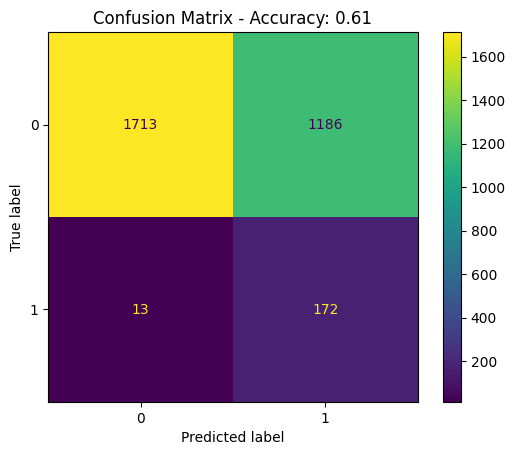

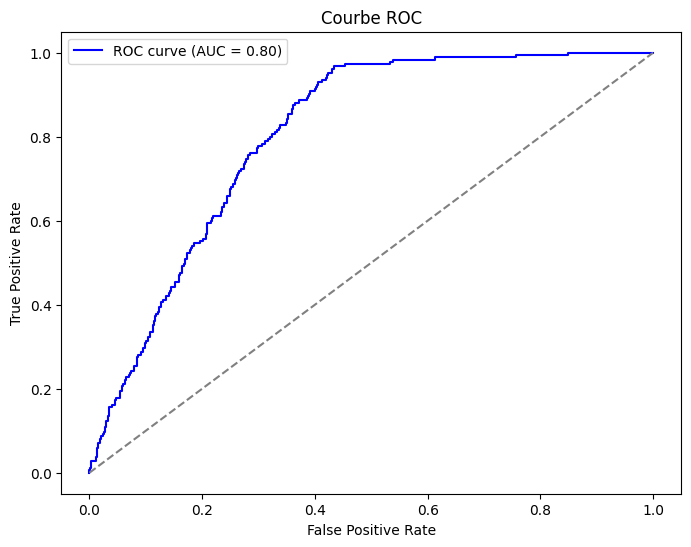

In [24]:
# Regression Logistique

print("\nCréation du pipeline avec préprocessing et modèle...")
pipeline_logReg = Pipeline([
    ('preprocessor', preprocessor),                  # Proprcessor
    ('logistic', LogisticRegression(penalty=None, class_weight='balanced', max_iter=1000))              # Modèle de régression logistique
])



# Entrainement et prédiction du modèle
pipeline_logReg.fit(X_train, y_train)
y_pred = pipeline_logReg.predict(X_test)

# probabilities
y_prob = pipeline_logReg.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))



acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix - Accuracy: {acc:.2f}")
plt.show()


# Calcul de la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Tracé de la courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label="ROC curve (AUC = {:.2f})".format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()

## Modele RandomForest


Création du pipeline avec préprocessing et modèle...
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       1.00      0.01      0.02       185

    accuracy                           0.94      3084
   macro avg       0.97      0.51      0.50      3084
weighted avg       0.94      0.94      0.91      3084



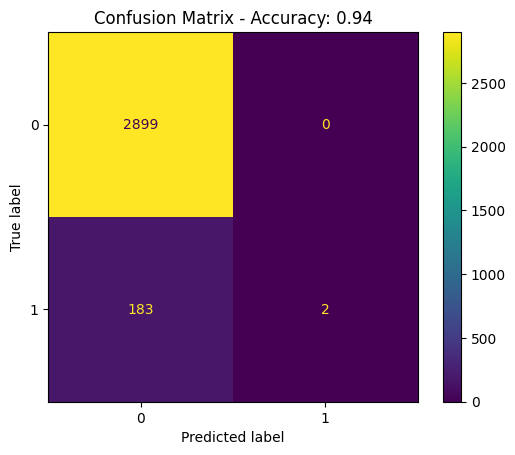

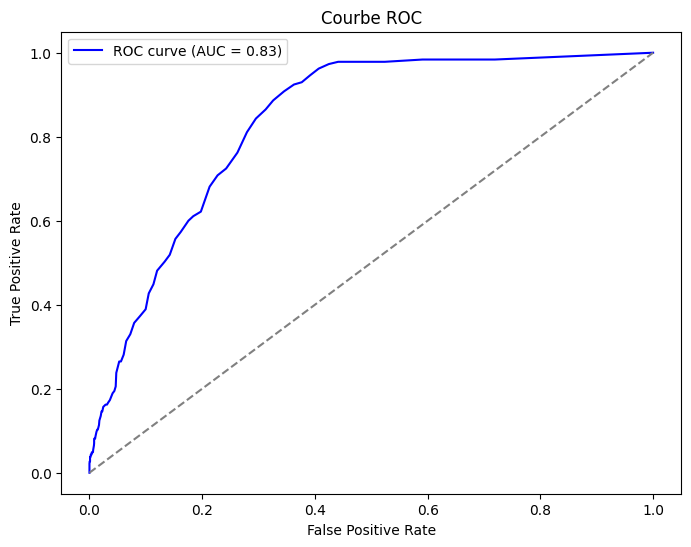

In [ ]:
# Modele RandomForest
print("\nCréation du pipeline avec préprocessing et modèle...")


random_preprocessor = ColumnTransformer([
    
   ("num", Pipeline(steps=[('imputer', SimpleImputer())]), numeric_columns),
    
    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns)
])

pipeline_random = Pipeline([
    ('preprocessor', random_preprocessor),                  # Proprcessor
    ('random', RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200,))              # Modèle de foret aléatoire
])

# Entrainement et prédiction du modèle
pipeline_random.fit(X_train, y_train)
y_pred = pipeline_random.predict(X_test)

# probabilities
y_prob = pipeline_random.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))



acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix - Accuracy: {acc:.2f}")
plt.show()


# Calcul de la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Tracé de la courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label="ROC curve (AUC = {:.2f})".format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()

# Ne détecte pratiquement pas les cas de fraude. Car le recall est de 0.01 => Detecte 2 cas de fraude sur 185
# Donc risque de ne pas retenir ce modèle. Pour les cas de ce type de fraude , c'est probalement très couteux de
# ne pas detecter les fraudes. Donc un modèle qui detecte mieux les fraudes est préférables dans notre cas.

## Modèle Boost
Modèle utilise est CatBoost car le dataset contient beaucoup de features catégorielles


Création du pipeline avec préprocessing et modèle CatBoost...
Learning rate set to 0.248809
0:	learn: 0.5803373	total: 11.6ms	remaining: 1.15s
1:	learn: 0.5260384	total: 17.6ms	remaining: 862ms
2:	learn: 0.5044682	total: 27.2ms	remaining: 880ms
3:	learn: 0.4847455	total: 34.1ms	remaining: 819ms
4:	learn: 0.4764825	total: 43.5ms	remaining: 826ms
5:	learn: 0.4688268	total: 55.7ms	remaining: 873ms
6:	learn: 0.4665743	total: 63.9ms	remaining: 848ms
7:	learn: 0.4643828	total: 71.4ms	remaining: 821ms
8:	learn: 0.4622054	total: 78ms	remaining: 789ms
9:	learn: 0.4543928	total: 86.1ms	remaining: 775ms
10:	learn: 0.4459848	total: 94ms	remaining: 760ms
11:	learn: 0.4450214	total: 101ms	remaining: 743ms
12:	learn: 0.4416065	total: 107ms	remaining: 719ms
13:	learn: 0.4397044	total: 113ms	remaining: 695ms
14:	learn: 0.4343801	total: 118ms	remaining: 671ms
15:	learn: 0.4263486	total: 124ms	remaining: 654ms
16:	learn: 0.4231964	total: 130ms	remaining: 637ms
17:	learn: 0.4120070	total: 137ms	remaining

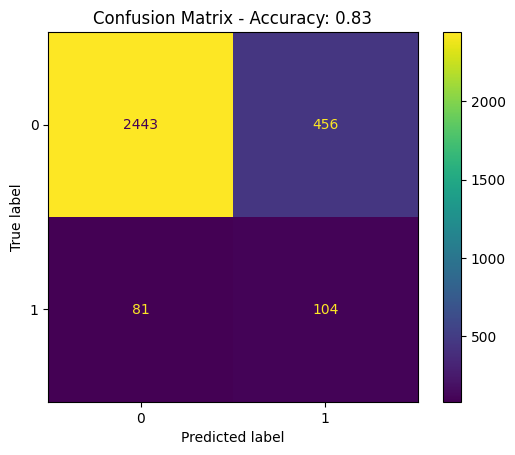

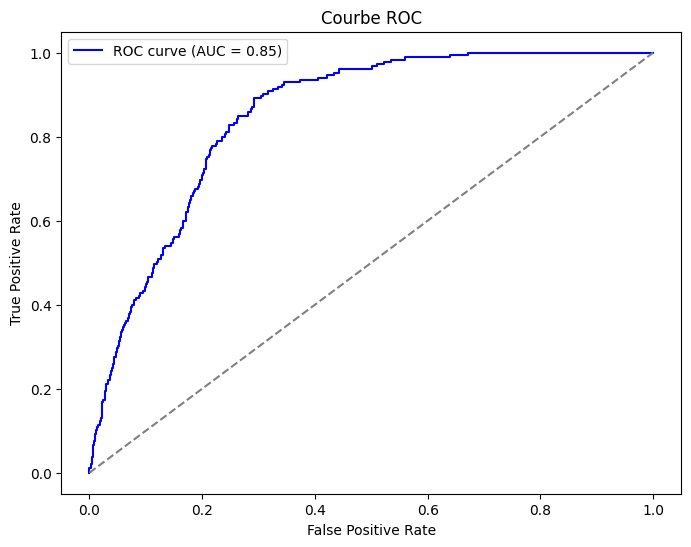

In [ ]:
# Modele XGBoost
print("\nCréation du pipeline avec préprocessing et modèle CatBoost...")


boost_preprocessor = ColumnTransformer([
    
   ("num", Pipeline(steps=[('imputer', SimpleImputer())]), numeric_columns),
    
    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns)
])

pipeline_boost = Pipeline([
    ('preprocessor', boost_preprocessor),                  # Proprcessor
    ('boosting', CatBoostClassifier(iterations=100, auto_class_weights='Balanced'))              # Modèle Boost
])

# Entrainement et prédiction du modèle
pipeline_boost.fit(X_train, y_train)
y_pred = pipeline_boost.predict(X_test)

# probabilities
y_prob = pipeline_boost.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))



acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix - Accuracy: {acc:.2f}")
plt.show()


# Calcul de la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Tracé de la courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label="ROC curve (AUC = {:.2f})".format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()

Après une première phase d’évaluation, deux modèles ont été retenus pour approfondissement : Logistic Regression et CatBoost. Ces modèles présentent les meilleurs résultats sur la classe minoritaire. Une phase de tuning est ensuite réalisée afin d’évaluer leur potentiel réel et d’identifier le meilleur compromis entre détection des fraudes et limitation des faux positifs.